# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities? 
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

df = pd.read_csv('data/airbnb_hw.csv')

In [2]:
# 1 - Data Cleaning

# remove any NAs in case
df_clean = df.dropna(subset=['Price']).copy()

# convert to Numeric
df_clean['Price'] = pd.to_numeric(df_clean['Price'].astype(str).str.replace('$', '').str.replace(',', ''), errors='coerce')

# make sure no 0s or invalid prices
df_clean = df_clean[df_clean['Price'] > 0]

# Remove rows with missing values
df_clean = df_clean.dropna()

print(f"Clean dataset shape: {df_clean.shape}")
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")

Clean dataset shape: (22010, 13)
Remaining missing values: 0


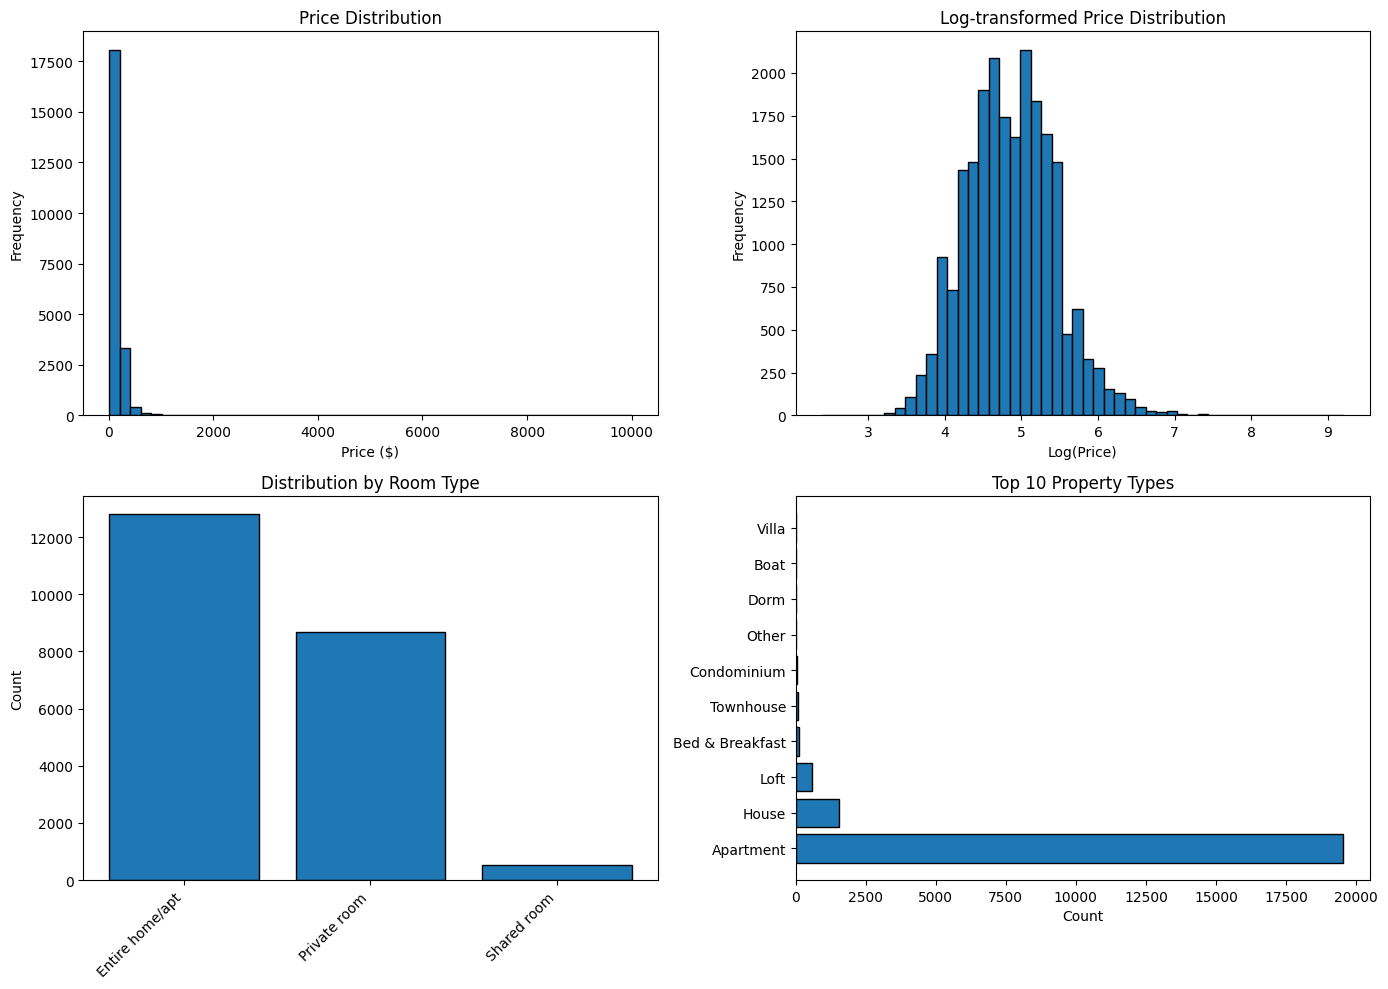

Categorical variables:
Room Type: ['Private room' 'Entire home/apt' 'Shared room']
Property Type: 18 unique values


In [3]:
# EDA Visualization of the data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# price distribution
axes[0, 0].hist(df_clean['Price'], bins=50, edgecolor='black')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price ($)')
axes[0, 0].set_ylabel('Frequency')

# log price distribution
axes[0, 1].hist(np.log1p(df_clean['Price']), bins=50, edgecolor='black')
axes[0, 1].set_title('Log-transformed Price Distribution')
axes[0, 1].set_xlabel('Log(Price)')
axes[0, 1].set_ylabel('Frequency')

# room type distribution
room_type_counts = df_clean['Room Type'].value_counts()
axes[1, 0].bar(room_type_counts.index, room_type_counts.values, edgecolor='black')
axes[1, 0].set_title('Distribution by Room Type')
axes[1, 0].set_ylabel('Count')
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# top 10 property types 
prop_type_counts = df_clean['Property Type'].value_counts().head(10)
axes[1, 1].barh(prop_type_counts.index, prop_type_counts.values, edgecolor='black')
axes[1, 1].set_title('Top 10 Property Types')
axes[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print("Categorical variables:")
print(f"Room Type: {df_clean['Room Type'].unique()}")
print(f"Property Type: {df_clean['Property Type'].nunique()} unique values")

In [4]:
# 2 - Transform Categorical Variables
df_model = df_clean.copy()

# Select numeric features for modeling
features_to_use = ['Beds', 'Number Of Reviews', 'Review Scores Rating']
numeric_features = [col for col in features_to_use if col in df_model.columns]

# One-hot encode categorical variables
df_model_encoded = df_model.copy()

# Encode Room Type
room_type_dummies = pd.get_dummies(df_model['Room Type'], prefix='RoomType', drop_first=True)
df_model_encoded = pd.concat([df_model_encoded, room_type_dummies], axis=1)

# Encode Neighbourhood
neighbourhood_dummies = pd.get_dummies(df_model['Neighbourhood '], prefix='Neighbourhood', drop_first=True)
df_model_encoded = pd.concat([df_model_encoded, neighbourhood_dummies], axis=1)

# Drop original categorical columns
df_model_encoded = df_model_encoded.drop(['Room Type', 'Neighbourhood ', 'Property Type', 'Host Since', 'Name', 'Zipcode'], axis=1, errors='ignore')

# Keep only numeric and encoded features
feature_cols = [col for col in df_model_encoded.columns if col not in ['Host Id', 'Price']]
feature_cols = [col for col in feature_cols if col in numeric_features + list(room_type_dummies.columns) + list(neighbourhood_dummies.columns)]

print(f"Final feature count: {len(feature_cols)}")
print(f"\nModel data shape: {df_model_encoded.shape}")

Final feature count: 9

Model data shape: (22010, 13)


In [5]:
# 3 - Implement 80/20 train-test split

# use features specificalyl related to price and encoded categorical variables
simple_features = []
for col in numeric_features:
    if col in df_model_encoded.columns and not df_model_encoded[col].isnull().all():
        simple_features.append(col)

print(f"Simple numeric features: {simple_features}")

# Prepare data 
X_data = df_model_encoded[simple_features].copy()
y_data = df_model_encoded['Price'].copy()

print(f"Data shape for modeling: X={X_data.shape}, y={y_data.shape}")

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

print(f"\nTrain set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Train/Test ratio: {len(X_train)/(len(X_train)+len(X_test)):.1%} / {len(X_test)/(len(X_train)+len(X_test)):.1%}")

Simple numeric features: ['Beds', 'Number Of Reviews', 'Review Scores Rating']
Data shape for modeling: X=(22010, 3), y=(22010,)

Train set size: (17608, 3)
Test set size: (4402, 3)
Train/Test ratio: 80.0% / 20.0%


In [6]:
# 4 - Build simple linear models with no transformations or interactions


def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

# # model 1 - all features 
model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred_train_m1 = model1.predict(X_train)
y_pred_test_m1 = model1.predict(X_test)

rmse_train_m1, r2_train_m1 = calculate_metrics(y_train, y_pred_train_m1)
rmse_test_m1, r2_test_m1 = calculate_metrics(y_test, y_pred_test_m1)

print("Simple model 1 - All features")
print(f"Training Set - RMSE: ${rmse_train_m1:.2f}, R²: {r2_train_m1:.4f}")
print(f"Test Set     - RMSE: ${rmse_test_m1:.2f}, R²: {r2_test_m1:.4f}")
print(f"Overfitting indicator (R² diff): {r2_train_m1 - r2_test_m1:.4f}")

print(X_train.columns)
# Model 2 - Number of Reviews data only
X_train_single = X_train[['Number Of Reviews']]
X_test_single = X_test[['Number Of Reviews']]

model2 = LinearRegression()
model2.fit(X_train_single, y_train)

y_pred_train_m2 = model2.predict(X_train_single)
y_pred_test_m2 = model2.predict(X_test_single)

rmse_train_m2, r2_train_m2 = calculate_metrics(y_train, y_pred_train_m2)
rmse_test_m2, r2_test_m2 = calculate_metrics(y_test, y_pred_test_m2)

print("Simple model 2 - Number of Reviews only")
print(f"Training Set - RMSE: ${rmse_train_m2:.2f}, R²: {r2_train_m2:.4f}")
print(f"Test Set     - RMSE: ${rmse_test_m2:.2f}, R²: {r2_test_m2:.4f}")
print(f"Overfitting indicator (R² diff): {r2_train_m2 - r2_test_m2:.4f}")

# Model 3 - Review Scores Rating only
X_train_single = X_train[['Review Scores Rating']]
X_test_single = X_test[['Review Scores Rating']]

model3 = LinearRegression()
model3.fit(X_train_single, y_train)

y_pred_train_m3 = model3.predict(X_train_single)
y_pred_test_m3 = model3.predict(X_test_single)

rmse_train_m3, r2_train_m3 = calculate_metrics(y_train, y_pred_train_m3)
rmse_test_m3, r2_test_m3 = calculate_metrics(y_test, y_pred_test_m3)

print("Simple model 3 - Review Scores Rating only")
print(f"Training Set - RMSE: ${rmse_train_m3:.2f}, R²: {r2_train_m3:.4f}")
print(f"Test Set     - RMSE: ${rmse_test_m3:.2f}, R²: {r2_test_m3:.4f}")
print(f"Overfitting indicator (R² diff): {r2_train_m3 - r2_test_m3:.4f}")

print("Of the simple models, the one using all features performs the best.")

Simple model 1 - All features
Training Set - RMSE: $140.91, R²: 0.1351
Test Set     - RMSE: $124.83, R²: 0.1866
Overfitting indicator (R² diff): -0.0515
Index(['Beds', 'Number Of Reviews', 'Review Scores Rating'], dtype='object')
Simple model 2 - Number of Reviews only
Training Set - RMSE: $151.45, R²: 0.0009
Test Set     - RMSE: $138.46, R²: -0.0007
Overfitting indicator (R² diff): 0.0016
Simple model 3 - Review Scores Rating only
Training Set - RMSE: $151.20, R²: 0.0042
Test Set     - RMSE: $138.38, R²: 0.0005
Overfitting indicator (R² diff): 0.0037
Of the simple models, the one using all features performs the best.


['Beds', 'Number Of Reviews', 'Review Scores Rating']


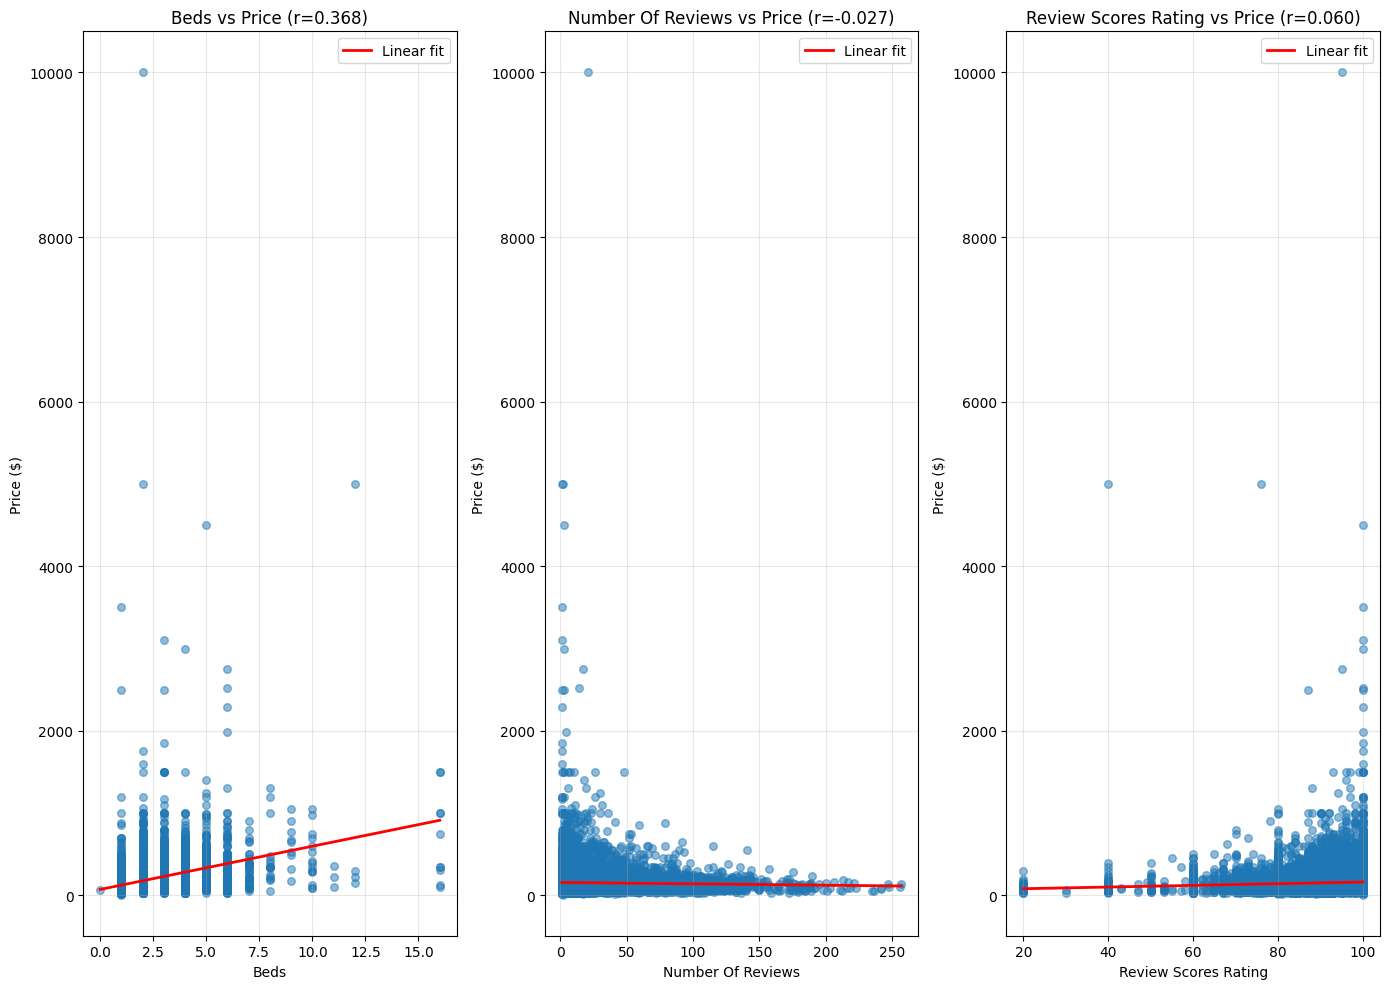

Beds:
  Linear correlation with Price: 0.3676

Number Of Reviews:
  Linear correlation with Price: -0.0269

Review Scores Rating:
  Linear correlation with Price: 0.0605

Overall, there is not much correlation across the variables


In [7]:
# 5 - Partial Correlation Plots

X_all = pd.concat([X_train, X_test])
y_all = pd.concat([y_train, y_test])

fig, axes = plt.subplots(1, 3, figsize=(14, 10))
axes = axes.flatten()
print(simple_features)
plot_idx = 0
for feature in simple_features[:3]:
    if plot_idx < 3:
        ax = axes[plot_idx]
        
        ax.scatter(X_all[feature], y_all, alpha=0.5, s=30)
        
        z = np.polyfit(X_all[feature], y_all, 1)
        p = np.poly1d(z)
        x_trend = np.linspace(X_all[feature].min(), X_all[feature].max(), 100)
        ax.plot(x_trend, p(x_trend), "r-", linewidth=2, label='Linear fit')
        
        correlation = X_all[feature].corr(y_all)
        ax.set_xlabel(feature)
        ax.set_ylabel('Price ($)')
        ax.set_title(f'{feature} vs Price (r={correlation:.3f})')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plot_idx += 1

plt.tight_layout()
plt.show()

for feature in simple_features:
    corr_linear = X_all[feature].corr(y_all)
    print(f"{feature}:")
    print(f"  Linear correlation with Price: {corr_linear:.4f}")
    print()

print("Overall, there is not much correlation across the variables")

In [ ]:
# 6 - Build Complex Models with Transformations and Interactions

def create_enhanced_features(X, y=None, fit=True):
    X_enhanced = X.copy()
    
    for col in simple_features:
        if (X[col] >= 0).all():
            X_enhanced[f'{col}_log'] = np.log1p(X[col])
    
    for col in simple_features:
        X_enhanced[f'{col}_squared'] = X[col] ** 2
    
    if len(simple_features) >= 2:
        X_enhanced[f'{simple_features[0]}_x_{simple_features[1]}'] = X[simple_features[0]] * X[simple_features[1]]
    
    return X_enhanced

# create features for train and test
X_train_enhanced = create_enhanced_features(X_train)
X_test_enhanced = create_enhanced_features(X_test)

print(f"Original features: {X_train.shape[1]}")
print(f"Enhanced features: {X_train_enhanced.shape[1]}")

# complex model 4 
model4 = LinearRegression()
model4.fit(X_train_enhanced, y_train)

y_pred_train_m4 = model4.predict(X_train_enhanced)
y_pred_test_m4 = model4.predict(X_test_enhanced)

rmse_train_m4, r2_train_m4 = calculate_metrics(y_train, y_pred_train_m4)
rmse_test_m4, r2_test_m4 = calculate_metrics(y_test, y_pred_test_m4)

print("Model 4 - Enhanced Features (Transformations + Interactions)")
print(f"Training Set - RMSE: ${rmse_train_m4:.2f}, R²: {r2_train_m4:.4f}")
print(f"Test Set     - RMSE: ${rmse_test_m4:.2f}, R²: {r2_test_m4:.4f}")
print(f"Overfitting indicator (R² diff): {r2_train_m4 - r2_test_m4:.4f}")

print("The more complex model performs better than the simple models. It has a higher R2 and lower RMSE")

Original features: 3
Enhanced features: 10
Model 4 - Enhanced Features (Transformations + Interactions)
Training Set - RMSE: $140.42, R²: 0.1411
Test Set     - RMSE: $124.32, R²: 0.1932
Overfitting indicator (R² diff): -0.0520
The more complex model performs better than the simple models. It has a higher R2 and lower RMSE


# 7 - Summary

The results from 1-6 show that having a more complex model with things like log transformations and interaction terms can improve the relationships between different features in data. Although this adds levels of complexity to the models, the increased performance helps analyze for better accuracy. Ths means improve R² values.

Something that I learned about overfitting is that it usually occurs when the training R² is greater than the test R², due to poor generalization. I also learned that underfitting occurs when the model is just too simple especially when training and testing performacne is poor. 

As said above, model selection is best when there is minimal overfitting and underfitting to ensure that the data performs well on the testing data. It is also important to understand which complex variables are necessary when constructing different additional layers of a model.